# Two POVs + frozen feature extractor + regressor

This notebook trains and evaluates different combinations of frozen feature extractors, POV fusion strategies and regressors on the top+side dataset.


In [1]:
import datetime
import warnings
from IPython.display import display
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.model_selection import ParameterGrid
from sklearn.svm import SVR
from src.helpers import *
from src.frozen_pipeline import *
from src.training_an_evaluation import *

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)


## Setup


In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
OUTER_SPLITS = 5
INNER_SPLITS = 5

CSV_PATH = Path("experiments/experiments_1_36.csv")
TOP_FOLDER = Path("photos/top_view_images")
SIDE_FOLDER = Path("photos/side_view_images")
EMBEDDING_CACHE_DIR = Path("embeddings")
EMBEDDING_CACHE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(exist_ok=True)

BACKBONE_NAMES = [
    "resnet50",
    "convnext_tiny",
    "densenet121",
]

FUSION_NAMES = [
    "concat",
    "mean",
    "max",
    "concat_abs_diff",
]

REGRESSION_MODEL_CONFIGS = {
    "dummy_mean": (
        DummyRegressor(strategy="mean"),
        {},
    ),

    "ridge": (
        make_pipeline(Ridge()),
        {
            "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
        },
    ),

    "elasticnet": (
        make_pipeline(ElasticNet(max_iter=20000)),
        {
            "model__alpha":    [0.0001, 0.001, 0.01, 0.1, 1.0],
            "model__l1_ratio": [0.1, 0.2, 0.5, 0.8, 0.9],
        },
    ),

    "random_forest": (
        # No scaler needed for trees, but consistency yk
        Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("model",   RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)),
        ]),
        {
            "model__n_estimators":    [100, 300, 500],
            # "model__max_depth":       [None, 5, 10]   # Seemed to always select None anyway
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features":    [0.3, 0.5, 1.0]
        },
    ),

    "svr": (
        make_pipeline(SVR()),
        {
            "model__C": [0.1, 1, 10, 100],
            "model__gamma": ["scale", 0.01, 0.1],
            "model__epsilon": [0.01, 0.1, 1]
        }
    ),

    # "extra_trees": (
    #     Pipeline([
    #         ("imputer", SimpleImputer(strategy="mean")),
    #         ("model",   ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=1)),
    #     ]),
    #     {
    #         "model__n_estimators":    [100, 300, 500],
    #         # "model__max_depth":       [None, 5, 10],
    #         "model__min_samples_leaf":[1, 2, 4],
    #         "model__max_features":    [0.3, 0.5, 1.0],
    #     },
    # ),
}


## Data loading


In [3]:
samples, image_paths = load_image_paths(CSV_PATH, TOP_FOLDER, SIDE_FOLDER)
print("Samples shape:", samples.shape)
display(samples[["exp_id", "volume", "top_path", "side_path"]].head())


Samples shape: (140, 23)


,exp_id,volume,top_path,side_path
0,1,38,photos/top_view_images/P2090072.JPG,photos/side_view_images/P2090161.JPG
1,1,57,photos/top_view_images/P2090073.JPG,photos/side_view_images/P2090163.JPG
2,1,76,photos/top_view_images/P2090074.JPG,photos/side_view_images/P2090167.JPG
3,2,19,photos/top_view_images/P2090075.JPG,photos/side_view_images/P2090171.JPG
4,2,38,photos/top_view_images/P2090076.JPG,photos/side_view_images/P2090173.JPG


## Regression model configuration


In [4]:
print("Grid sizes per regressor:")
for name, (_, grid) in REGRESSION_MODEL_CONFIGS.items():
    n = len(list(ParameterGrid(grid))) if grid else 1
    print(f"  {name:15s}: {n:4d}")

Grid sizes per regressor:
  dummy_mean     :    1
  ridge          :    7
  elasticnet     :   25
  random_forest  :   27
  svr            :   36


## Nested CV evaluation over backbone, fusion and regression model combinations (split by experiment IDs)

In [5]:
all_results = []
nested_artifacts = {}

for backbone_name in BACKBONE_NAMES:
    for fusion_name in FUSION_NAMES:
        print(f"\n{'#'*90}")
        print(f"Evaluating backbone={backbone_name}, fusion={fusion_name}")
        print(f"{'#'*90}")

        X, y, groups = build_feature_matrix(samples, backbone_name, fusion_name, EMBEDDING_CACHE_DIR, DEVICE)
        nested_results, oof_predictions = run_nested_cv(
            X=X,
            y=y,
            groups=groups,
            model_configs=REGRESSION_MODEL_CONFIGS,
            outer_splits=OUTER_SPLITS,
            inner_splits=INNER_SPLITS,
        )

        summary_df = summarise_nested_results(nested_results, backbone_name, fusion_name)
        all_results.append(summary_df)
        nested_artifacts[(backbone_name, fusion_name)] = {
            "X": X,
            "y": y,
            "groups": groups,
            "nested_results": nested_results,
            "oof_predictions": oof_predictions,
        }

results_df = pd.concat(all_results, ignore_index=True).sort_values(
    ["cv_mae_mean", "cv_rmse_mean", "cv_r2_mean"],
    ascending=[True, True, False],
).reset_index(drop=True)



##########################################################################################
Evaluating backbone=resnet50, fusion=concat
##########################################################################################


resnet50 + concat: 100%|██████████| 140/140 [00:00<00:00, 3368.13it/s]


GroupKFold | dummy_mean
Fold 1: MAE=19.000, RMSE=21.243, R2=0.0, best={}
Fold 2: MAE=19.000, RMSE=21.243, R2=0.0, best={}
Fold 3: MAE=19.000, RMSE=21.248, R2=-0.0014411340842916953, best={}
Fold 4: MAE=18.657, RMSE=20.940, R2=-0.003915733416869127, best={}
Fold 5: MAE=19.355, RMSE=21.557, R2=-0.0004091064763893648, best={}

GroupKFold | ridge


Fold 1: MAE=6.068, RMSE=7.774, R2=0.866070695735359, best={'model__alpha': 1000.0}
Fold 2: MAE=48.920, RMSE=220.531, R2=-106.77582553357816, best={'model__alpha': 1000.0}
Fold 3: MAE=7.402, RMSE=8.725, R2=0.8311364405329976, best={'model__alpha': 1000.0}
Fold 4: MAE=6.974, RMSE=9.170, R2=0.8074683596976786, best={'model__alpha': 1000.0}
Fold 5: MAE=7.857, RMSE=9.684, R2=0.7981069004408725, best={'model__alpha': 1000.0}

GroupKFold | elasticnet
Fold 1: MAE=6.078, RMSE=8.126, R2=0.853659664696985, best={'model__alpha': 0.1, 'model__l1_ratio': 0.5}
Fold 2: MAE=8.020, RMSE=9.790, R2=0.787594143882466, best={'model__alpha': 1.0, 'model__l1_ratio': 0.9}
Fold 3: MAE=7.183, RMSE=8.660, R2=0.8336647329303971, best={'model__alpha': 1.0, 'model__l1_ratio': 0.1}
Fold 4: MAE=7.417, RMSE=9.320, R2=0.8011375495103104, best={'model__alpha': 1.0, 'model__l1_ratio': 0.9}
Fold 5: MAE=8.158, RMSE=9.776, R2=0.7942431055196673, best={'model__alpha': 1.0, 'model__l1_ratio': 0.8}

GroupKFold | random_forest
F

,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_stc,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,resnet50,concat,elasticnet,7.371196,0.741373,83.861181,11.715191,9.134419,0.650825,0.814060,0.025348
1,resnet50,concat,random_forest,9.108757,0.994380,117.698689,17.229228,10.820028,0.791001,0.739063,0.037503
2,resnet50,concat,svr,10.911302,0.831138,176.179292,25.510889,13.238267,0.963113,0.610134,0.049799
3,resnet50,concat,ridge,15.444327,16.748022,9789.655727,19422.095844,51.176855,84.679308,-20.694609,43.040615
4,resnet50,concat,dummy_mean,19.002491,0.220582,451.432182,8.290007,21.246038,0.195063,-0.001153,0.001478


...


##########################################################################################
Evaluating backbone=densenet121, fusion=concat_abs_diff
##########################################################################################


densenet121 + concat_abs_diff: 100%|██████████| 140/140 [00:00<00:00, 3729.43it/s]


GroupKFold | dummy_mean
Fold 1: MAE=19.000, RMSE=21.243, R2=0.0, best={}
Fold 2: MAE=19.000, RMSE=21.243, R2=0.0, best={}
Fold 3: MAE=19.000, RMSE=21.248, R2=-0.0014411340842916953, best={}
Fold 4: MAE=18.657, RMSE=20.940, R2=-0.003915733416869127, best={}
Fold 5: MAE=19.355, RMSE=21.557, R2=-0.0004091064763893648, best={}

GroupKFold | ridge


Fold 1: MAE=5.876, RMSE=7.299, R2=0.8819461570993576, best={'model__alpha': 100.0}
Fold 2: MAE=5.922, RMSE=7.210, R2=0.8847979237209189, best={'model__alpha': 0.001}
Fold 3: MAE=6.132, RMSE=7.824, R2=0.864230569937267, best={'model__alpha': 100.0}
Fold 4: MAE=7.748, RMSE=9.751, R2=0.7822897478185675, best={'model__alpha': 10.0}
Fold 5: MAE=5.876, RMSE=7.691, R2=0.8726653797171617, best={'model__alpha': 100.0}

GroupKFold | elasticnet
Fold 1: MAE=5.700, RMSE=7.368, R2=0.8797038441738955, best={'model__alpha': 0.01, 'model__l1_ratio': 0.1}
Fold 2: MAE=5.640, RMSE=7.025, R2=0.890623847410933, best={'model__alpha': 0.01, 'model__l1_ratio': 0.1}
Fold 3: MAE=6.201, RMSE=8.045, R2=0.8564550009589919, best={'model__alpha': 1.0, 'model__l1_ratio': 0.2}
Fold 4: MAE=7.782, RMSE=9.441, R2=0.7959200973916684, best={'model__alpha': 0.01, 'model__l1_ratio': 0.1}
Fold 5: MAE=5.572, RMSE=7.030, R2=0.8936041849080338, best={'model__alpha': 1.0, 'model__l1_ratio': 0.2}

GroupKFold | random_forest
Fold 1:

,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_stc,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,densenet121,concat_abs_diff,elasticnet,6.179155,0.831781,61.382454,14.962913,7.781785,0.908996,0.863261,0.036113
1,densenet121,concat_abs_diff,ridge,6.310709,0.724639,64.140607,15.856687,7.954918,0.927304,0.857186,0.038142
2,densenet121,concat_abs_diff,svr,8.070825,0.544632,91.636800,8.044139,9.563544,0.418839,0.796550,0.020029
3,densenet121,concat_abs_diff,random_forest,8.522197,0.915717,109.568355,29.452354,10.382186,1.333631,0.757040,0.065070
4,densenet121,concat_abs_diff,dummy_mean,19.002491,0.220582,451.432182,8.290007,21.246038,0.195063,-0.001153,0.001478


## Inspect selected hyperparameters


In [6]:
for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    print(f"\n{'='*90}")
    print(f"backbone={backbone_name}, fusion={fusion_name}")
    print(f"{'='*90}")
    for regressor_name, folds in artifact["nested_results"].items():
        has_params = any(f["best_params"] for f in folds)
        if not has_params:
            continue
        print(regressor_name)
        for f in folds:
            print(f"  Fold {f['fold']}: {f['best_params']}")
        print()


backbone=resnet50, fusion=concat
ridge
  Fold 1: {'model__alpha': 1000.0}
  Fold 2: {'model__alpha': 1000.0}
  Fold 3: {'model__alpha': 1000.0}
  Fold 4: {'model__alpha': 1000.0}
  Fold 5: {'model__alpha': 1000.0}

elasticnet
  Fold 1: {'model__alpha': 0.1, 'model__l1_ratio': 0.5}
  Fold 2: {'model__alpha': 1.0, 'model__l1_ratio': 0.9}
  Fold 3: {'model__alpha': 1.0, 'model__l1_ratio': 0.1}
  Fold 4: {'model__alpha': 1.0, 'model__l1_ratio': 0.9}
  Fold 5: {'model__alpha': 1.0, 'model__l1_ratio': 0.8}

random_forest
  Fold 1: {'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
  Fold 2: {'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
  Fold 3: {'model__max_features': 0.5, 'model__min_samples_leaf': 2, 'model__n_estimators': 100}
  Fold 4: {'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
  Fold 5: {'model__max_features': 0.3, 'model__min_samples_leaf': 1, 'model__n_estimators'

## Best performing configurations
Print results and plot out-of-fold predictions for the best configurations.


,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_stc,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,densenet121,concat,elasticnet,6.147815,0.655581,62.870070,12.551599,7.892194,0.763770,0.860157,0.030333
1,densenet121,concat_abs_diff,elasticnet,6.179155,0.831781,61.382454,14.962913,7.781785,0.908996,0.863261,0.036113
2,densenet121,concat_abs_diff,ridge,6.310709,0.724639,64.140607,15.856687,7.954918,0.927304,0.857186,0.038142
3,densenet121,concat,ridge,6.400277,0.662146,66.386159,15.312748,8.095260,0.923541,0.852393,0.036099
4,convnext_tiny,concat_abs_diff,ridge,6.644675,0.366407,67.581765,6.950247,8.210534,0.410961,0.850025,0.016036
5,densenet121,max,elasticnet,6.648489,0.745216,73.577011,19.457034,8.513082,1.050923,0.836076,0.046821
6,densenet121,max,ridge,6.671067,0.600072,74.076037,15.043031,8.566748,0.828778,0.835134,0.036743
7,convnext_tiny,mean,elasticnet,6.673197,0.842783,65.971089,13.394612,8.079622,0.831144,0.853790,0.029200
8,densenet121,mean,ridge,6.742740,0.369753,73.346296,12.749120,8.532824,0.732942,0.836947,0.030850
9,convnext_tiny,concat,ridge,6.792104,0.457617,67.652433,8.430974,8.209550,0.505697,0.849872,0.019157


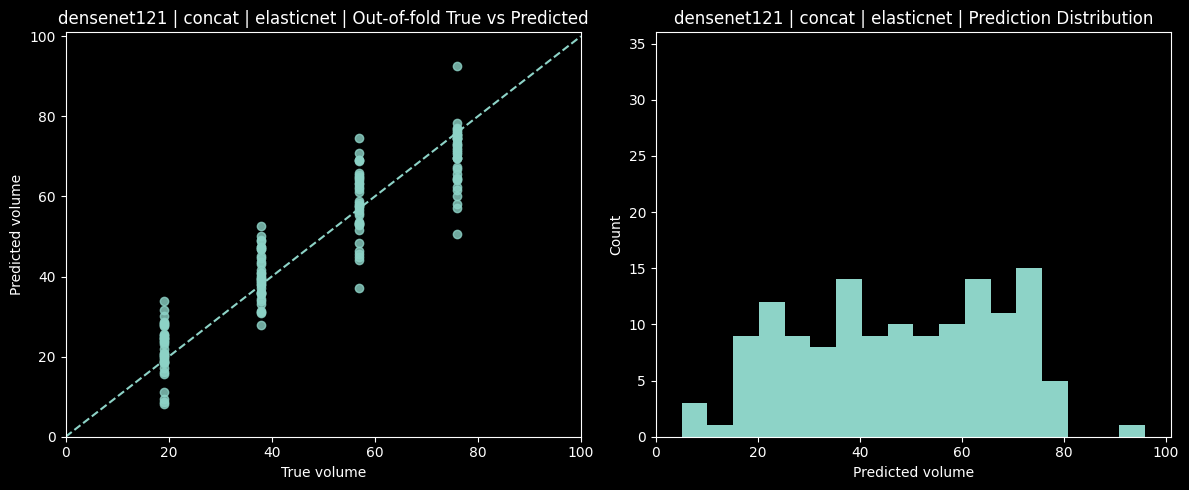

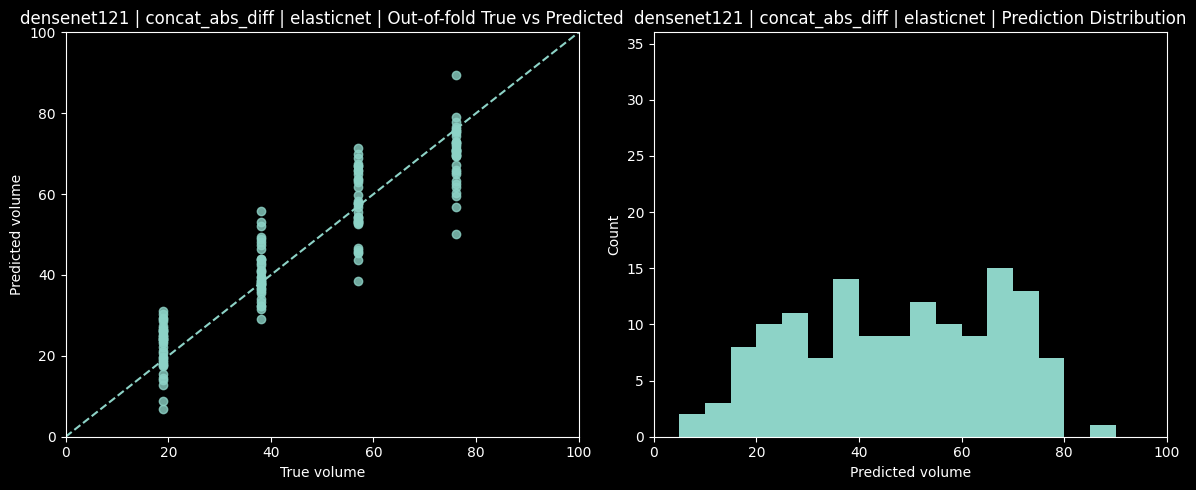

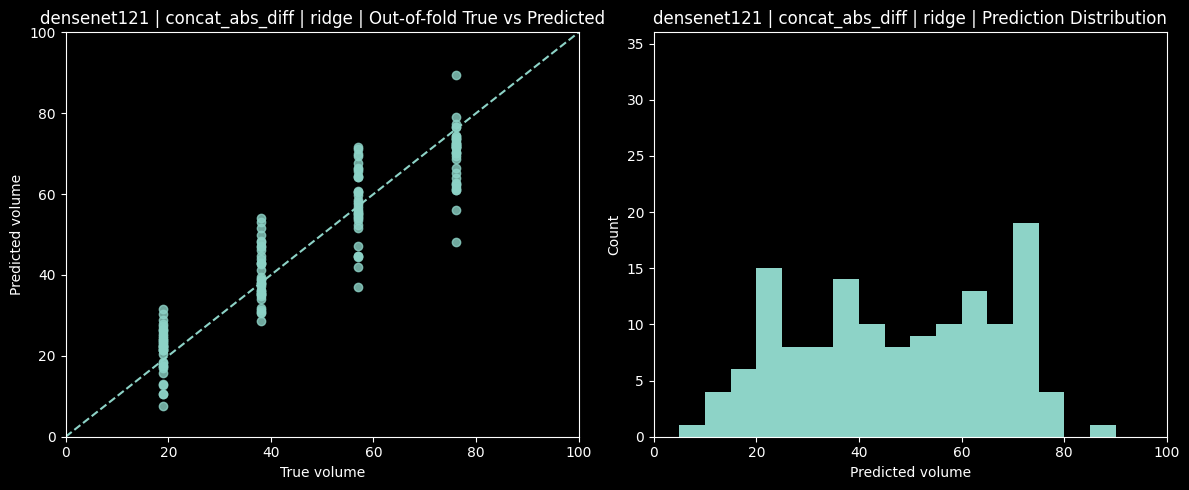

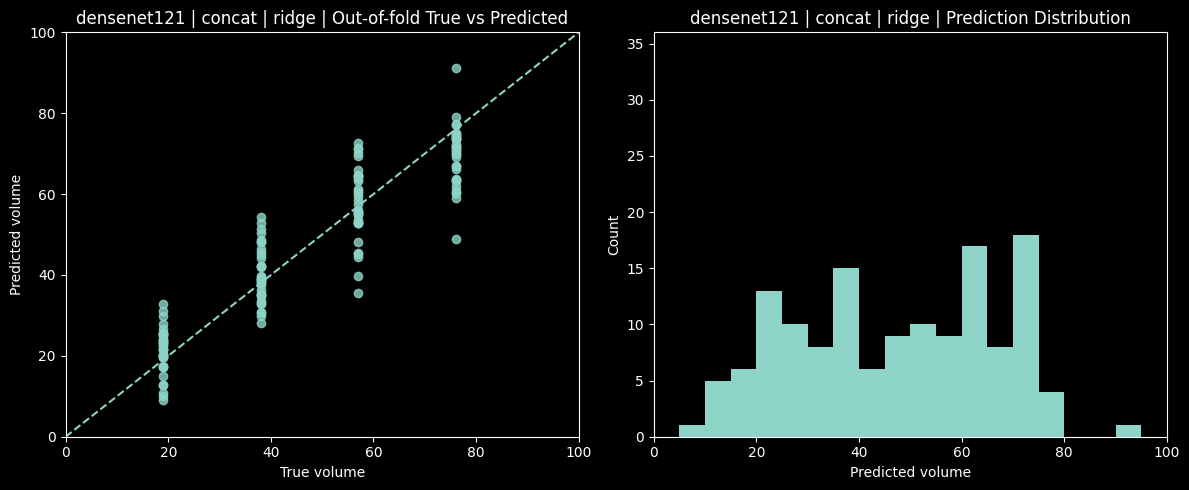

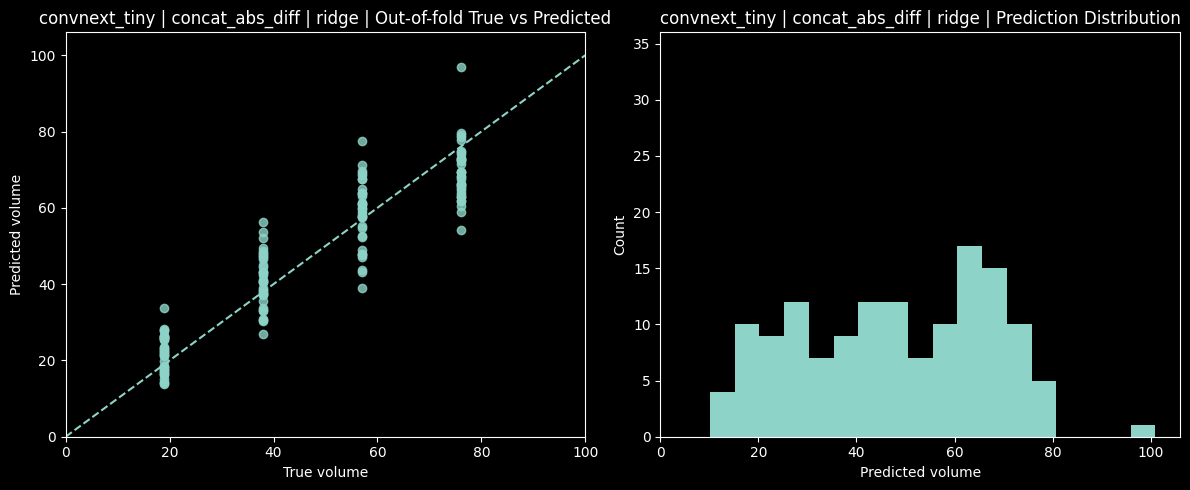

In [18]:
display(results_df)

for _, row in results_df.head(5).iterrows():
    key = (row["backbone"], row["fusion"])
    artifact = nested_artifacts[key]
    y_true = artifact["y"]
    y_pred = artifact["oof_predictions"][row["regressor"]]
    title = f"{row['backbone']} | {row['fusion']} | {row['regressor']}"
    make_oof_plot(y_true, y_pred, title_prefix=title)


## Save results


In [37]:
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
name = f"results_frozen_{timestamp}.csv"
results_df.to_csv(OUTPUT_DIR / name, index=False)
print("Saved:", OUTPUT_DIR / name)


Saved: results/results_frozen_2026-03-20_10-58-18.csv


## Nested CV evaluation over backbone, fusion and regression model combinations (split by volume size)

In [9]:
all_lovo_rows = []
all_lovo_results = {}
all_lovo_oof_predictions = {}

for backbone_name in BACKBONE_NAMES:
    for fusion_name in FUSION_NAMES:
        print(f"\n{'#'*90}")
        print(f"LOVO | backbone={backbone_name} | fusion={fusion_name}")
        print(f"{'#'*90}")

        X, y, exp_groups = build_feature_matrix(
            samples=samples,
            backbone_name=backbone_name,
            fusion_name=fusion_name,
            cache_dir=EMBEDDING_CACHE_DIR,
            device=DEVICE,
        )

        volume_groups = y.copy()

        lovo_results, lovo_oof_predictions = run_lovo_cv(
            X=X,
            y=y,
            exp_groups=exp_groups,         # inner CV grouped by experiment
            volume_groups=volume_groups,   # outer CV = leave one volume out
            model_configs=REGRESSION_MODEL_CONFIGS,
            inner_splits=5,
        )

        all_lovo_results[(backbone_name, fusion_name)] = lovo_results
        all_lovo_oof_predictions[(backbone_name, fusion_name)] = lovo_oof_predictions

        summary_df = summarise_nested_results(
            lovo_results,
            backbone_name=backbone_name,
            fusion_name=fusion_name,
        )

        all_lovo_rows.append(summary_df)

all_lovo_summary = pd.concat(all_lovo_rows, ignore_index=True).sort_values(
    ["cv_mae_mean", "cv_rmse_mean"]
).reset_index(drop=True)


##########################################################################################
LOVO | backbone=resnet50 | fusion=concat
##########################################################################################


resnet50 + concat: 100%|██████████| 140/140 [00:00<00:00, 4051.07it/s]


LOVO | dummy_mean
Fold 1 | test_volume=19.0: MAE=38.000, RMSE=38.000, R2=nan, best={}
Fold 2 | test_volume=38.0: MAE=12.667, RMSE=12.667, R2=nan, best={}
Fold 3 | test_volume=57.0: MAE=12.667, RMSE=12.667, R2=nan, best={}
Fold 4 | test_volume=76.0: MAE=38.000, RMSE=38.000, R2=nan, best={}

LOVO | ridge


Fold 1 | test_volume=19.0: MAE=12.106, RMSE=13.196, R2=nan, best={'model__alpha': 1000.0}
Fold 2 | test_volume=38.0: MAE=31.600, RMSE=132.606, R2=nan, best={'model__alpha': 1000.0}
Fold 3 | test_volume=57.0: MAE=5.934, RMSE=7.826, R2=nan, best={'model__alpha': 1000.0}
Fold 4 | test_volume=76.0: MAE=17.698, RMSE=18.316, R2=nan, best={'model__alpha': 100.0}

LOVO | elasticnet
Fold 1 | test_volume=19.0: MAE=10.232, RMSE=11.624, R2=nan, best={'model__alpha': 0.001, 'model__l1_ratio': 0.5}
Fold 2 | test_volume=38.0: MAE=8.611, RMSE=10.713, R2=nan, best={'model__alpha': 1.0, 'model__l1_ratio': 0.9}
Fold 3 | test_volume=57.0: MAE=7.191, RMSE=9.587, R2=nan, best={'model__alpha': 0.1, 'model__l1_ratio': 0.5}
Fold 4 | test_volume=76.0: MAE=16.464, RMSE=17.426, R2=nan, best={'model__alpha': 0.001, 'model__l1_ratio': 0.1}

LOVO | random_forest
Fold 1 | test_volume=19.0: MAE=25.097, RMSE=25.181, R2=nan, best={'model__max_features': 0.3, 'model__min_samples_leaf': 4, 'model__n_estimators': 100}
Fold

,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_stc,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,resnet50,concat,elasticnet,10.624420,3.538810,161.370924,83.569764,12.337708,3.025209,NaN,NaN
1,resnet50,concat,ridge,16.834449,9.485907,4538.817995,7532.528521,42.985786,51.875236,NaN,NaN
2,resnet50,concat,svr,17.663931,10.273472,436.938129,350.046184,18.544073,9.646527,NaN,NaN
3,resnet50,concat,random_forest,19.194213,7.007936,434.810523,224.327667,19.788585,6.574376,NaN,NaN
4,resnet50,concat,dummy_mean,25.333333,12.666667,802.222222,641.777778,25.333333,12.666667,NaN,NaN


...


##########################################################################################
LOVO | backbone=densenet121 | fusion=concat_abs_diff
##########################################################################################


densenet121 + concat_abs_diff: 100%|██████████| 140/140 [00:00<00:00, 3334.90it/s]


LOVO | dummy_mean
Fold 1 | test_volume=19.0: MAE=38.000, RMSE=38.000, R2=nan, best={}
Fold 2 | test_volume=38.0: MAE=12.667, RMSE=12.667, R2=nan, best={}
Fold 3 | test_volume=57.0: MAE=12.667, RMSE=12.667, R2=nan, best={}
Fold 4 | test_volume=76.0: MAE=38.000, RMSE=38.000, R2=nan, best={}

LOVO | ridge


Fold 1 | test_volume=19.0: MAE=6.908, RMSE=8.017, R2=nan, best={'model__alpha': 100.0}
Fold 2 | test_volume=38.0: MAE=4.878, RMSE=6.556, R2=nan, best={'model__alpha': 10.0}
Fold 3 | test_volume=57.0: MAE=6.874, RMSE=8.224, R2=nan, best={'model__alpha': 10.0}
Fold 4 | test_volume=76.0: MAE=13.112, RMSE=13.990, R2=nan, best={'model__alpha': 100.0}

LOVO | elasticnet
Fold 1 | test_volume=19.0: MAE=6.720, RMSE=7.913, R2=nan, best={'model__alpha': 0.01, 'model__l1_ratio': 0.1}
Fold 2 | test_volume=38.0: MAE=6.042, RMSE=7.901, R2=nan, best={'model__alpha': 1.0, 'model__l1_ratio': 0.8}
Fold 3 | test_volume=57.0: MAE=6.144, RMSE=7.493, R2=nan, best={'model__alpha': 1.0, 'model__l1_ratio': 0.2}
Fold 4 | test_volume=76.0: MAE=12.129, RMSE=13.156, R2=nan, best={'model__alpha': 0.1, 'model__l1_ratio': 0.1}

LOVO | random_forest
Fold 1 | test_volume=19.0: MAE=21.546, RMSE=21.578, R2=nan, best={'model__max_features': 1.0, 'model__min_samples_leaf': 2, 'model__n_estimators': 100}
Fold 2 | test_volume

,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_stc,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,densenet121,concat_abs_diff,elasticnet,7.758720,2.536274,88.566758,48.866200,9.115725,2.338870,NaN,NaN
1,densenet121,concat_abs_diff,ridge,7.942991,3.095570,92.652240,60.259195,9.196694,2.841314,NaN,NaN
2,densenet121,concat_abs_diff,svr,13.907386,7.301769,262.744529,195.937487,14.786328,6.641463,NaN,NaN
3,densenet121,concat_abs_diff,random_forest,15.678167,6.984006,311.291754,204.807140,16.488523,6.278563,NaN,NaN
4,densenet121,concat_abs_diff,dummy_mean,25.333333,12.666667,802.222222,641.777778,25.333333,12.666667,NaN,NaN


## Best performing configurations
Print results and plot out-of-fold predictions for the best configurations.

,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_stc,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,densenet121,concat_abs_diff,elasticnet,7.758720,2.536274,88.566758,48.866200,9.115725,2.338870,NaN,NaN
1,densenet121,max,ridge,7.893495,3.197611,93.032973,64.309979,9.179989,2.959860,NaN,NaN
2,densenet121,concat,ridge,7.933298,2.673566,91.581874,53.389299,9.235025,2.509219,NaN,NaN
3,densenet121,concat_abs_diff,ridge,7.942991,3.095570,92.652240,60.259195,9.196694,2.841314,NaN,NaN
4,convnext_tiny,mean,ridge,8.102405,2.945429,94.680551,56.348058,9.374965,2.605874,NaN,NaN
5,densenet121,concat,elasticnet,8.234521,3.571351,102.804694,78.877885,9.540195,3.433566,NaN,NaN
6,densenet121,max,elasticnet,8.235944,3.400322,101.015415,70.035726,9.561090,3.098545,NaN,NaN
7,densenet121,mean,elasticnet,8.497400,3.917420,108.887378,88.045192,9.755233,3.704431,NaN,NaN
8,convnext_tiny,mean,elasticnet,8.666689,3.251633,107.037289,65.954984,9.928658,2.908443,NaN,NaN
9,densenet121,mean,ridge,8.670703,4.499425,113.934011,101.756153,9.829707,4.160634,NaN,NaN


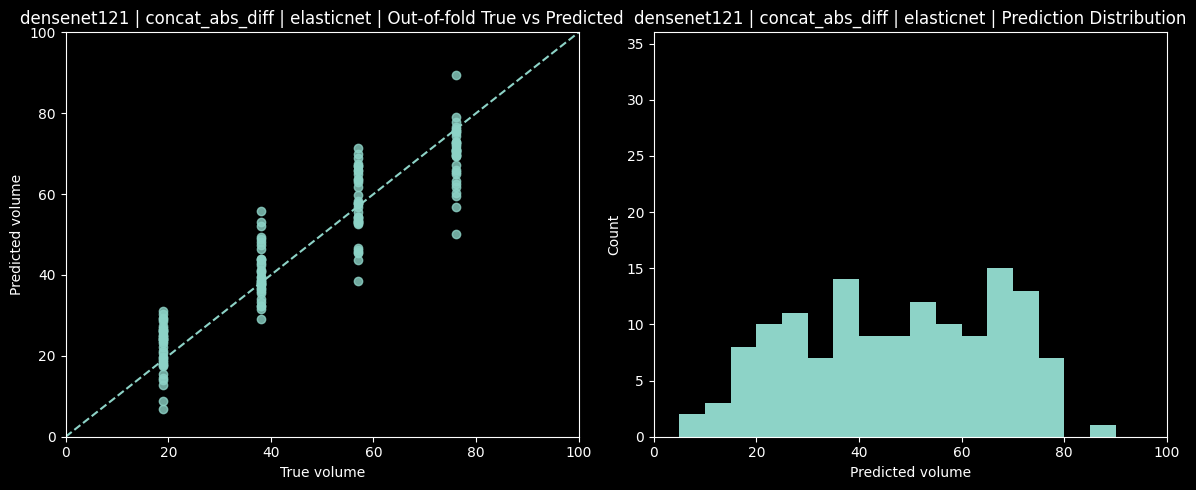

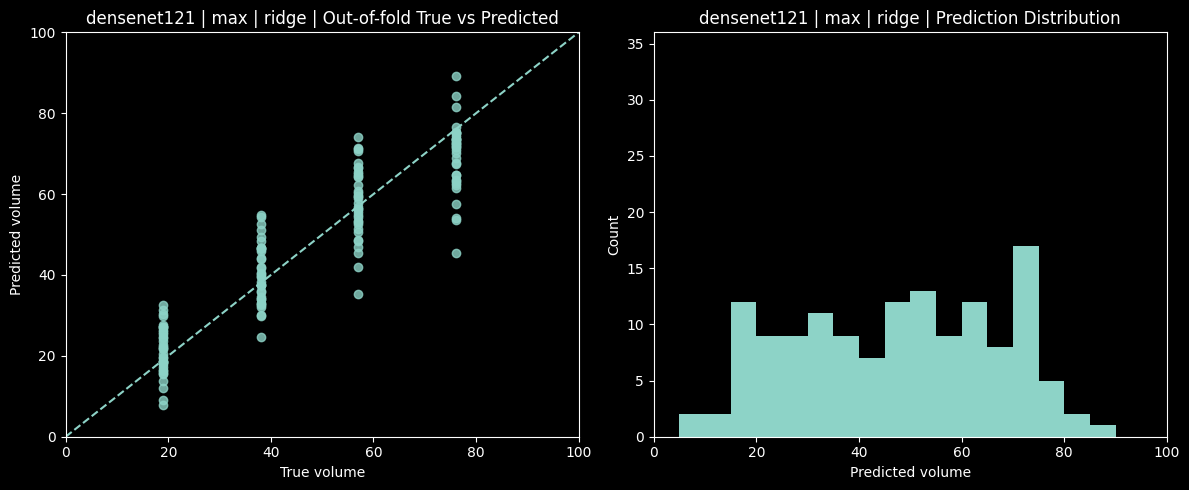

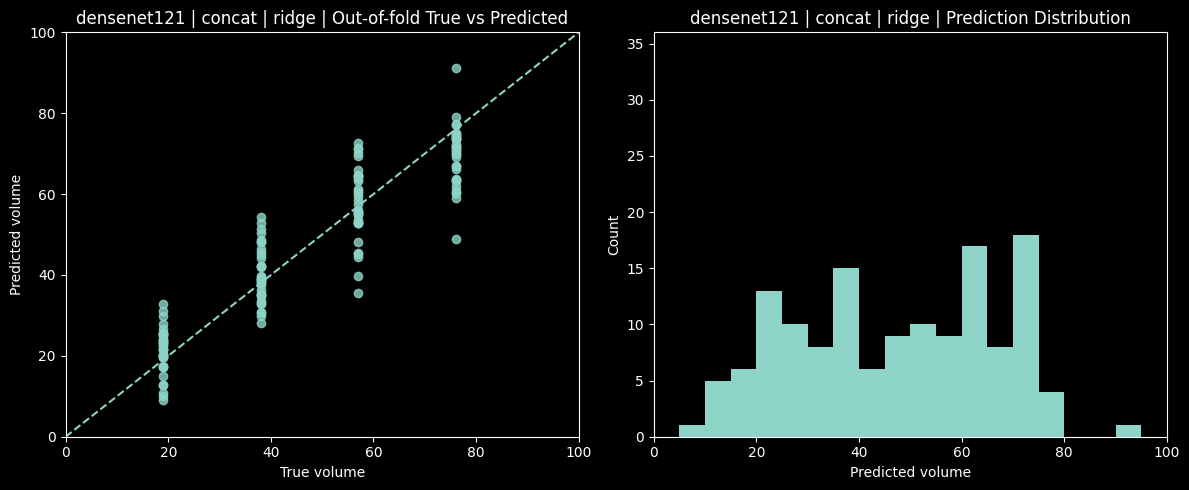

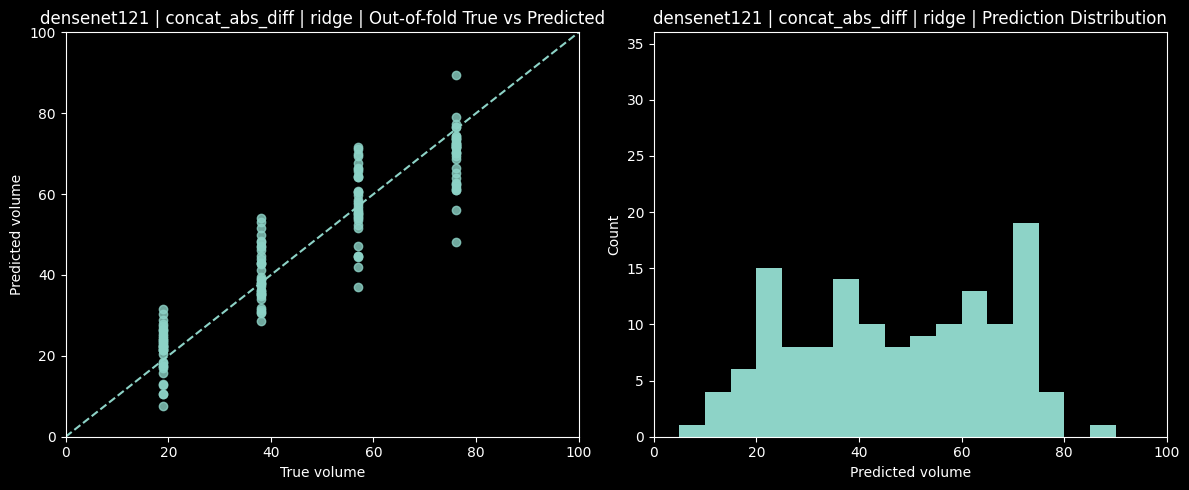

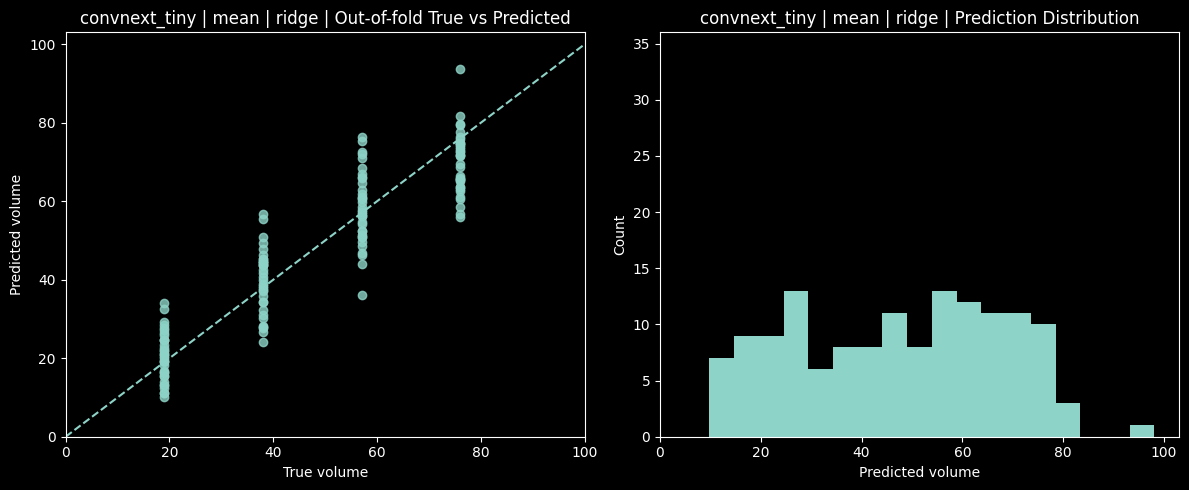

In [19]:
display(all_lovo_summary)

for _, row in all_lovo_summary.head(5).iterrows():
    key = (row["backbone"], row["fusion"])
    artifact = nested_artifacts[key]
    y_true = artifact["y"]
    y_pred = artifact["oof_predictions"][row["regressor"]]
    title = f"{row['backbone']} | {row['fusion']} | {row['regressor']}"
    make_oof_plot(y_true, y_pred, title_prefix=title)

## Predictions per withheld volume

In [27]:
lovo_prediction_rows = []

for (backbone_name, fusion_name), model_dict in all_lovo_results.items():
    X_tmp, y_tmp, _ = build_feature_matrix(
        samples=samples,
        backbone_name=backbone_name,
        fusion_name=fusion_name,
        cache_dir=EMBEDDING_CACHE_DIR,
        device=DEVICE,
    )

    for model_name, folds in model_dict.items():
        y_pred = all_lovo_oof_predictions[(backbone_name, fusion_name)][model_name]

        for i in range(len(y_tmp)):
            lovo_prediction_rows.append({
                "backbone": backbone_name,
                "fusion": fusion_name,
                "model": model_name,
                "true_volume": y_tmp[i],
                "pred_volume": y_pred[i],
                "held_out_volume": y_tmp[i],
                "config": f"{backbone_name} | {fusion_name} | {model_name}",
            })

leave_one_volume_predictions = pd.DataFrame(lovo_prediction_rows)

densenet121 + concat_abs_diff: 100%|██████████| 140/140 [00:00<00:00, 4084.46it/s]


,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_stc,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,densenet121,concat_abs_diff,elasticnet,7.758720,2.536274,88.566758,48.866200,9.115725,2.338870,NaN,NaN
1,densenet121,max,ridge,7.893495,3.197611,93.032973,64.309979,9.179989,2.959860,NaN,NaN
2,densenet121,concat,ridge,7.933298,2.673566,91.581874,53.389299,9.235025,2.509219,NaN,NaN
3,densenet121,concat_abs_diff,ridge,7.942991,3.095570,92.652240,60.259195,9.196694,2.841314,NaN,NaN
4,convnext_tiny,mean,ridge,8.102405,2.945429,94.680551,56.348058,9.374965,2.605874,NaN,NaN
5,densenet121,concat,elasticnet,8.234521,3.571351,102.804694,78.877885,9.540195,3.433566,NaN,NaN
6,densenet121,max,elasticnet,8.235944,3.400322,101.015415,70.035726,9.561090,3.098545,NaN,NaN
7,densenet121,mean,elasticnet,8.497400,3.917420,108.887378,88.045192,9.755233,3.704431,NaN,NaN
8,convnext_tiny,mean,elasticnet,8.666689,3.251633,107.037289,65.954984,9.928658,2.908443,NaN,NaN
9,densenet121,mean,ridge,8.670703,4.499425,113.934011,101.756153,9.829707,4.160634,NaN,NaN


Predicted volumes on the held-out sets, for each selected config:


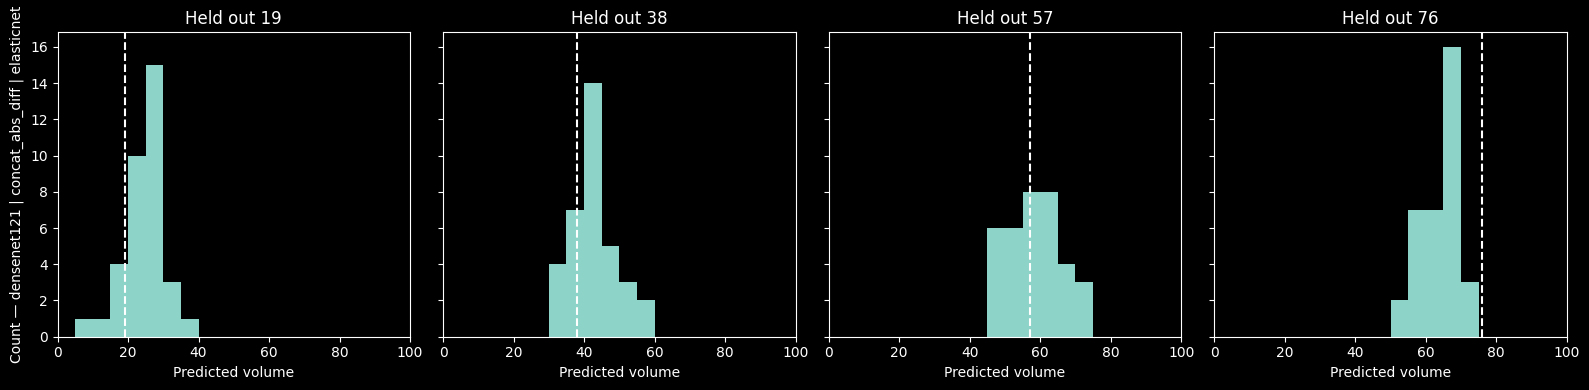

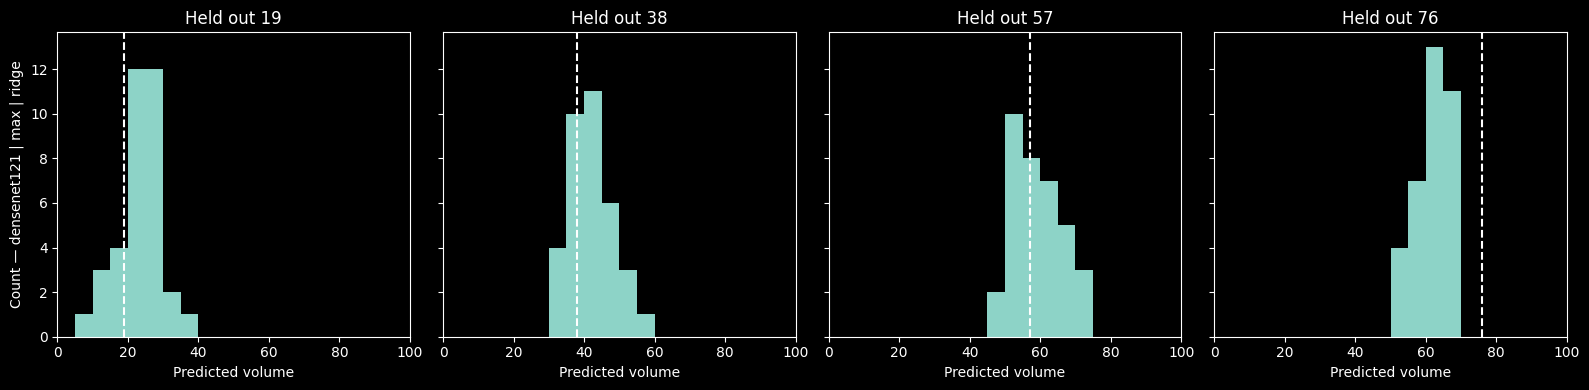

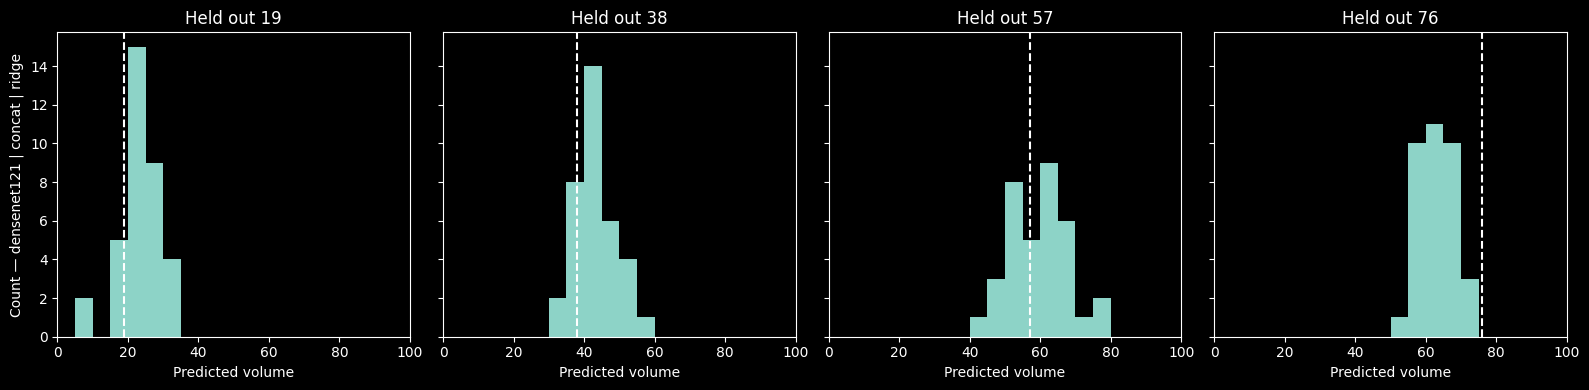

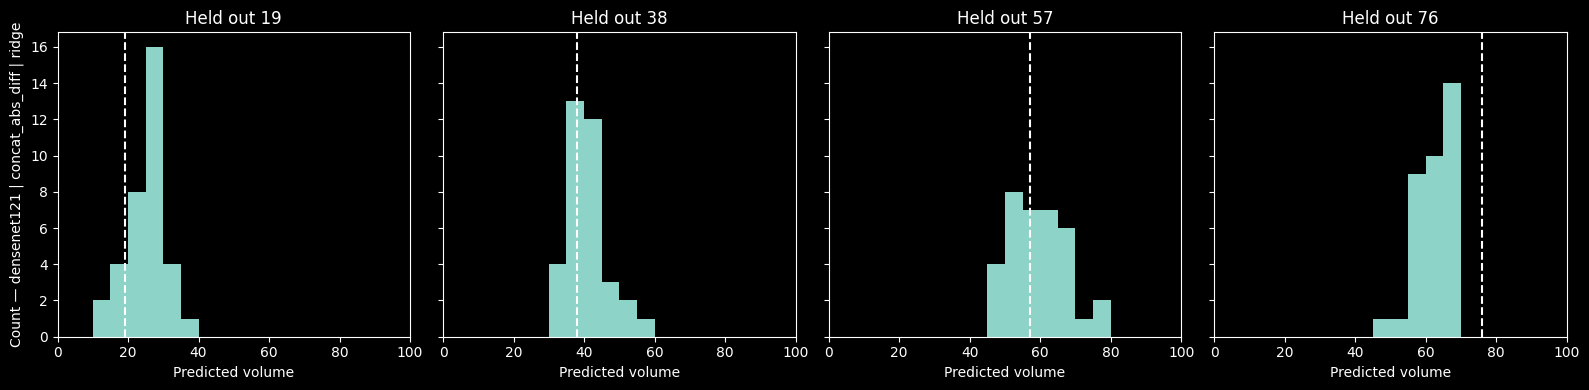

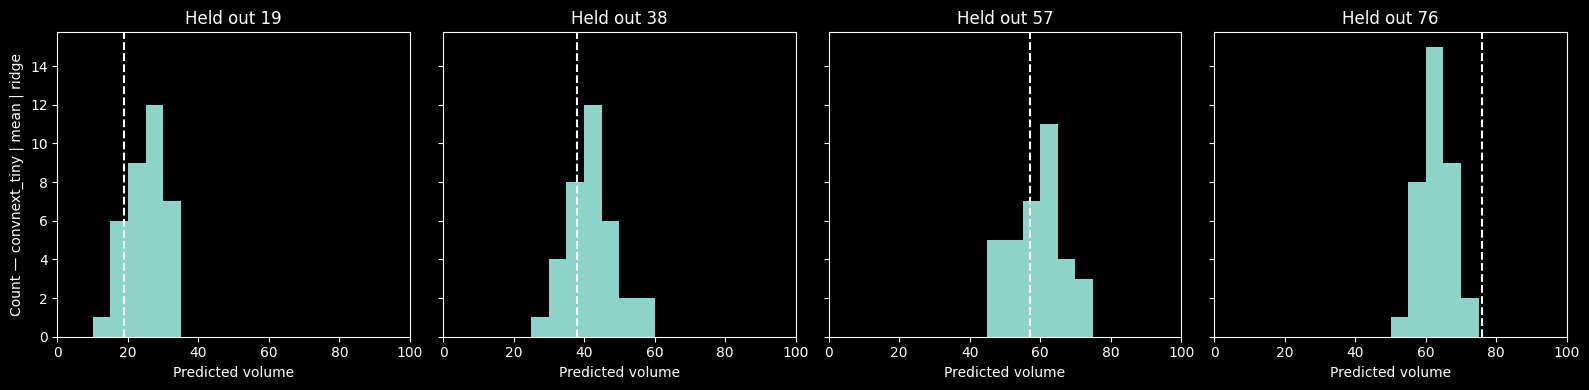

In [28]:
unique_volumes = np.sort(leave_one_volume_predictions["held_out_volume"].unique())

display(all_lovo_summary.head(10))
PLOT_CONFIGS = all_lovo_summary.head(5).apply(
    lambda row: f"{row['backbone']} | {row['fusion']} | {row['regressor']}",
    axis=1
).tolist()

print("Predicted volumes on the held-out sets, for each selected config:")

for config_name in PLOT_CONFIGS:
    predictions = leave_one_volume_predictions[
        leave_one_volume_predictions["config"] == config_name
    ].copy()

    fig, axes = plt.subplots(
        1, len(unique_volumes),
        figsize=(4 * len(unique_volumes), 4),
        sharey=True,
    )
    if len(unique_volumes) == 1:
        axes = [axes]

    for ax, vol in zip(axes, unique_volumes):
        subset = predictions[predictions["held_out_volume"] == vol]
        ax.hist(subset["pred_volume"], bins=20, range=(0, 100))
        ax.set_xlim(0, 100)
        ax.axvline(vol, linestyle="--")
        ax.set_title(f"Held out {int(vol)}")
        ax.set_xlabel("Predicted volume")

    axes[0].set_ylabel(f"Count — {config_name}")
    plt.tight_layout()
    plt.show()

In [36]:
mae_per_volume_rows = []

for config_name, df_cfg in leave_one_volume_predictions.groupby("config"):
    backbone_name, fusion_name, model_name = config_name.split(" | ")

    for vol, df_vol in df_cfg.groupby("held_out_volume"):
        mae = np.mean(np.abs(df_vol["pred_volume"] - df_vol["true_volume"]))

        mae_per_volume_rows.append({
            "backbone": backbone_name,
            "fusion": fusion_name,
            "model": model_name,
            "held_out_volume": vol,
            "mae": mae,
        })

mae_per_volume_df = pd.DataFrame(mae_per_volume_rows)

mae_per_volume_wide = (
    mae_per_volume_df.pivot_table(
        index=["backbone", "fusion", "model"],
        columns="held_out_volume",
        values="mae",
        aggfunc="mean",
    )
    .reset_index()
)

mae_per_volume_wide.columns.name = None
mae_per_volume_wide = mae_per_volume_wide.rename(columns={
    19.0: "mae_mean_19",
    38.0: "mae_mean_38",
    57.0: "mae_mean_57",
    76.0: "mae_mean_76",
})

display(mae_per_volume_wide.sort_values(["mae_mean_76"]))

,backbone,fusion,model,mae_mean_19,mae_mean_38,mae_mean_57,mae_mean_76
26,densenet121,concat_abs_diff,elasticnet,6.719844,6.041999,6.144221,12.128817
23,densenet121,concat,ridge,6.186626,6.258518,6.738608,12.549441
28,densenet121,concat_abs_diff,ridge,6.908462,4.877603,6.873756,13.112141
18,convnext_tiny,mean,ridge,6.781365,6.331427,6.110023,13.186805
33,densenet121,max,ridge,6.394831,5.494434,6.285584,13.399129
31,densenet121,max,elasticnet,6.879180,5.767152,6.212001,14.085445
16,convnext_tiny,mean,elasticnet,7.692524,6.664330,6.098834,14.211070
21,densenet121,concat,elasticnet,6.656759,5.528243,6.374764,14.378317
1,convnext_tiny,concat,elasticnet,8.360168,6.737196,6.789030,14.608033
13,convnext_tiny,max,ridge,8.754268,6.555529,6.669162,14.628170


## Save results

In [38]:
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
name = f"results_frozen_lovo_{timestamp}.csv"
all_lovo_summary.to_csv(OUTPUT_DIR / name, index=False)
print("Saved:", OUTPUT_DIR / name)

Saved: results/results_frozen_lovo_2026-03-20_10-58-27.csv
